# FICO Score Quantization — Optimal Bucket Construction

    Task: Map continuous FICO scores (300–850) to discrete rating buckets
            that best capture default risk, using two optimisation objectives:
    
      Method 1 — Minimise Mean Squared Error (MSE)
                 Treat bucketing as an approximation problem: find boundaries
                 such that within each bucket, all scores are represented by
                 the bucket mean with minimum squared deviation.
    
      Method 2 — Maximise Log-Likelihood (LL) via Dynamic Programming
                 Find boundaries that maximise the log-likelihood of observed
                 defaults given the within-bucket default rate, using a DP
                 approach that solves the problem in O(n² · B) time.
    
    Output
    
      - Rating map function: fico_to_rating(score, method, n_buckets)
      - Comparison plots across bucket counts
      - Summary tables for both methods


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import pearsonr

In [2]:
df = pd.read_csv("Loan_Data.csv")
fico   = df["fico_score"].values
default = df["default"].values

print(f"Records     : {len(fico):,}")
print(f"FICO range  : {fico.min()} – {fico.max()}")
print(f"Default rate: {default.mean():.2%}")


Records     : 10,000
FICO range  : 408 – 850
Default rate: 18.51%


# EDA: FICO vs Default

In [3]:
# Rolling default rate by FICO
fico_df = pd.DataFrame({"fico": fico, "default": default}).sort_values("fico")
fico_df["rolling_dr"] = fico_df["default"].rolling(200, center=True, min_periods=50).mean()

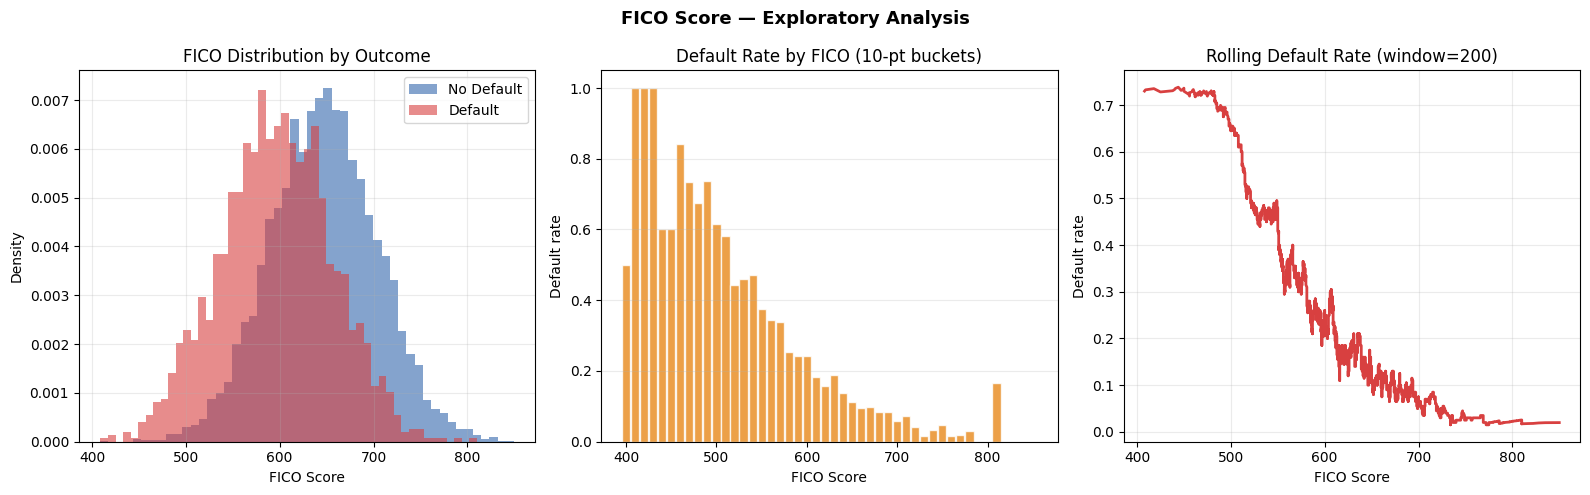

In [4]:
# Default rate in 10-point FICO buckets
fico_df["fico_10"] = (fico_df["fico"] // 10) * 10
bucket_dr = fico_df.groupby("fico_10").agg(
    n=("default", "count"),
    k=("default", "sum")
).reset_index()
bucket_dr["dr"] = bucket_dr["k"] / bucket_dr["n"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("FICO Score — Exploratory Analysis", fontsize=13, fontweight="bold")

ax = axes[0]
ax.hist(fico[default == 0], bins=50, alpha=0.6, color="#3266ad",
        density=True, label="No Default")
ax.hist(fico[default == 1], bins=50, alpha=0.6, color="#d84040",
        density=True, label="Default")
ax.set_title("FICO Distribution by Outcome")
ax.set_xlabel("FICO Score"); ax.set_ylabel("Density")
ax.legend(); ax.grid(True, alpha=0.25)

ax = axes[1]
ax.bar(bucket_dr["fico_10"], bucket_dr["dr"], width=9,
       color="#e8891a", alpha=0.8, edgecolor="white")
ax.set_title("Default Rate by FICO (10-pt buckets)")
ax.set_xlabel("FICO Score"); ax.set_ylabel("Default rate")
ax.grid(True, alpha=0.25, axis="y")

ax = axes[2]
ax.plot(fico_df["fico"], fico_df["rolling_dr"],
        color="#d84040", linewidth=2)
ax.set_title("Rolling Default Rate (window=200)")
ax.set_xlabel("FICO Score"); ax.set_ylabel("Default rate")
ax.grid(True, alpha=0.25)

plt.tight_layout()